# Feature Engineering - Messy Housing Dataset

Notebook này thực hiện các bước Feature Engineering theo hướng dẫn của `feature_engineering_guide.md` trên dữ liệu thô `messy_housing_data.csv`, thực hiện lọc các dòng bị khuyết thiếu biến mục tiêu và tạo thêm các đặc trưng tương tác diện tích x vị trí. Biến mục tiêu price được giữ nguyên thang gốc USD.

## Khởi tạo và Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression
import os

## Bước 0. Đọc dữ liệu & Chia Train/Test

Đọc bộ dữ liệu thô, loại bỏ các dòng bị khuyết thiếu biến mục tiêu `price` và chia Train/Test.

In [2]:
# 1. Đọc dữ liệu thô
data = pd.read_csv('../data/raw/messy_housing_data.csv')
print(f"Kích thước dữ liệu gốc: {data.shape[0]} dòng, {data.shape[1]} cột\n")

# 2. Tiền xử lý biến mục tiêu 'price' sang số
data['price'] = pd.to_numeric(data['price'], errors='coerce')

# 3. Loại bỏ các dòng bị khuyết thiếu biến mục tiêu price (NaN hoặc unavailable)
data = data.dropna(subset=['price'])
print(f"Kích thước dữ liệu sau khi loại bỏ dòng khuyết thiếu price: {data.shape[0]} dòng\n")

# 4. Tiền xử lý giá trị âm area_sqft = -100 thành NaN để điền khuyết bằng mean sau này
data.loc[data['area_sqft'] < 0, 'area_sqft'] = np.nan

# 5. Tách X và y
X = data.drop(columns=['price'])
y = data['price']

# 6. Chia tập Train/Test (80/20) trên 363 dòng sạch
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuyển y_train và y_test thành DataFrame để dễ xử lý tiếp
y_train = pd.DataFrame(y_train, columns=['price'])
y_test = pd.DataFrame(y_test, columns=['price'])

print(f"Kích thước tập Train: {X_train.shape[0]} dòng")
print(f"Kích thước tập Test: {X_test.shape[0]} dòng")

Kích thước dữ liệu gốc: 420 dòng, 6 cột

Kích thước dữ liệu sau khi loại bỏ dòng khuyết thiếu price: 363 dòng

Kích thước tập Train: 290 dòng
Kích thước tập Test: 73 dòng


## Bước 1. Xử Lý Giá Trị Thiếu (Handling Missing Values)

Sử dụng trị trung bình (mean) của tập Train để điền các giá trị thiếu trong các đặc trưng đầu vào X.

In [3]:
# Điền khuyết cho các cột số của X bằng mean của tập Train
num_cols = ['area_sqft', 'bedrooms', 'year_built']

imputer = SimpleImputer(strategy='mean')
# Fit imputer trên X_train và transform cả X_train, X_test
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

# Kiểm tra lại số lượng giá trị thiếu sau điền khuyết
print("Số lượng NaN trong X_train sau điền khuyết:")
print(X_train.isnull().sum())
print("\nSố lượng NaN trong X_test sau điền khuyết:")
print(X_test.isnull().sum())
print("\nSố lượng NaN trong y_train sau điền khuyết:", y_train.isnull().sum().sum())
print("Số lượng NaN trong y_test sau điền khuyết:", y_test.isnull().sum().sum())

Số lượng NaN trong X_train sau điền khuyết:
area_sqft     0
bedrooms      0
bathrooms     0
year_built    0
location      0
dtype: int64

Số lượng NaN trong X_test sau điền khuyết:
area_sqft     0
bedrooms      0
bathrooms     0
year_built    0
location      0
dtype: int64

Số lượng NaN trong y_train sau điền khuyết: 0
Số lượng NaN trong y_test sau điền khuyết: 0


## Bước 2. Xử Lý Giá Trị Ngoại Lệ (Handling Outliers)

Biến đổi logarit cho biến số liên tục area_sqft và capping cho biến rời rạc bedrooms dựa trên khoảng IQR Train.

In [4]:
# 1. Áp dụng biến đổi Logarit (np.log1p) cho biến số liên tục (area_sqft)
X_train['area_sqft_log'] = np.log1p(X_train['area_sqft'])
X_test['area_sqft_log'] = np.log1p(X_test['area_sqft'])

# 2. Giới hạn biên (Capping) cho biến rời rạc 'bedrooms' sử dụng IQR của tập Train
Q1_bed = X_train['bedrooms'].quantile(0.25)
Q3_bed = X_train['bedrooms'].quantile(0.75)
IQR_bed = Q3_bed - Q1_bed
lower_bound_bed = Q1_bed - 1.5 * IQR_bed
upper_bound_bed = Q3_bed + 1.5 * IQR_bed

# Capping cho bedrooms trên cả X_train và X_test
X_train['bedrooms'] = np.clip(X_train['bedrooms'], lower_bound_bed, upper_bound_bed)
X_test['bedrooms'] = np.clip(X_test['bedrooms'], lower_bound_bed, upper_bound_bed)

print(f"Biên trên bedrooms xác định từ Train: {upper_bound_bed}")
print(f"Max bedrooms trong Train sau capping: {X_train['bedrooms'].max()}")
print(f"Max bedrooms trong Test sau capping: {X_test['bedrooms'].max()}")

Biên trên bedrooms xác định từ Train: 9.5
Max bedrooms trong Train sau capping: 9.5
Max bedrooms trong Test sau capping: 9.5


## Bước 3. Tạo Đặc Trưng Mới (Feature Creation)

Chuẩn hóa địa điểm viết thường, gộp nhóm và trích xuất các đặc trưng tương tác số học.

In [5]:
# 1. Chuẩn hóa cột location thô thành 7 thành phố chuẩn
def clean_location(loc):
    if not isinstance(loc, str):
        return np.nan
    loc = loc.strip().lower()
    if loc in ['la', 'l.a.', 'los angeles']:
        return 'los angeles'
    if loc in ['sf', 'san francisco']:
        return 'san francisco'
    if loc in ['nyc', 'new york city']:
        return 'new york city'
    if loc in ['chicago', 'chicgo']:
        return 'chicago'
    if loc in ['boston', 'bostan']:
        return 'boston'
    return loc

X_train['location'] = X_train['location'].apply(clean_location)
X_test['location'] = X_test['location'].apply(clean_location)

# 2. Tạo các cột đặc trưng mới
# sqft_per_room
X_train['sqft_per_room'] = X_train['area_sqft'] / X_train['bedrooms']
X_test['sqft_per_room'] = X_test['area_sqft'] / X_test['bedrooms']

# bath_to_bed_ratio
X_train['bath_to_bed_ratio'] = X_train['bathrooms'] / X_train['bedrooms']
X_test['bath_to_bed_ratio'] = X_test['bathrooms'] / X_test['bedrooms']

# house_age (tuổi của căn nhà tính đến mốc thời gian 2026)
X_train['house_age'] = 2026 - X_train['year_built']
X_test['house_age'] = 2026 - X_test['year_built']

X_train.head()

,area_sqft,bedrooms,bathrooms,year_built,location,area_sqft_log,sqft_per_room,bath_to_bed_ratio,house_age
239,3579.0,1.0,2,1966.0,boston,8.183118,3579.0,2.000000,60.0
393,1303.0,5.0,5,1913.0,boston,7.173192,260.6,1.000000,113.0
414,1724.0,2.0,2,1912.0,miami,7.452982,862.0,1.000000,114.0
89,567.0,1.0,5,1951.0,new york city,6.342121,567.0,5.000000,75.0
98,4755.0,3.0,4,1905.0,miami,8.467162,1585.0,1.333333,121.0


## Bước 4. Categorical Encoding (Mã Hóa Biến Phân Loại)

Mã hóa One-Hot cho cột location phân loại thành các biến nhị phân.

In [6]:
# Sử dụng OneHotEncoder để mã hóa cột location thành đặc trưng nhị phân
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit trên X_train['location'] và transform cả X_train, X_test
ohe_cols_train = ohe.fit_transform(X_train[['location']])
ohe_cols_test = ohe.transform(X_test[['location']])

# Lấy tên cột mới sau mã hóa
ohe_feature_names = ohe.get_feature_names_out(['location'])
ohe_df_train = pd.DataFrame(ohe_cols_train, columns=ohe_feature_names, index=X_train.index)
ohe_df_test = pd.DataFrame(ohe_cols_test, columns=ohe_feature_names, index=X_test.index)

# Ghép các cột One-Hot mới vào DataFrame và loại bỏ cột location gốc
X_train_enc = pd.concat([X_train.drop(columns=['location']), ohe_df_train], axis=1)
X_test_enc = pd.concat([X_test.drop(columns=['location']), ohe_df_test], axis=1)

print("Các cột sau khi One-Hot Encoding:")
print(X_train_enc.columns.tolist())

Các cột sau khi One-Hot Encoding:
['area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'area_sqft_log', 'sqft_per_room', 'bath_to_bed_ratio', 'house_age', 'location_austin', 'location_boston', 'location_chicago', 'location_los angeles', 'location_miami', 'location_new york city', 'location_san francisco']


## Bước 5. Tạo đặc trưng tương tác & Chuẩn Hóa Biến Số (Interaction Features & Scaling)

In [7]:
# 1. Tạo các đặc trưng tương tác: area_sqft_log x location_*
loc_cols = [c for c in X_train_enc.columns if c.startswith('location_')]

for col in loc_cols:
    new_col_name = f"area_sqft_log_x_{col}"
    X_train_enc[new_col_name] = X_train_enc['area_sqft_log'] * X_train_enc[col]
    X_test_enc[new_col_name] = X_test_enc['area_sqft_log'] * X_test_enc[col]

print("Đã tạo thêm 7 đặc trưng tương tác. Danh sách tất cả các cột:")
print(X_train_enc.columns.tolist())

# 2. Xác định các cột số để scale (bao gồm cả các đặc trưng gốc và tương tác mới)
scale_cols = ['area_sqft_log', 'bedrooms', 'bathrooms', 'year_built', 'sqft_per_room', 'bath_to_bed_ratio', 'house_age'] + [f"area_sqft_log_x_{col}" for col in loc_cols]

scaler = StandardScaler()

# Fit scaler trên tập Train và transform cả Train và Test
X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train_enc[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test_enc[scale_cols])

# Loại bỏ cột area_sqft gốc để tránh dư thừa
X_train_final = X_train_scaled.drop(columns=['area_sqft'])
X_test_final = X_test_scaled.drop(columns=['area_sqft'])

print("\nKích thước X_train_final:", X_train_final.shape)
X_train_final.head()

Đã tạo thêm 7 đặc trưng tương tác. Danh sách tất cả các cột:
['area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'area_sqft_log', 'sqft_per_room', 'bath_to_bed_ratio', 'house_age', 'location_austin', 'location_boston', 'location_chicago', 'location_los angeles', 'location_miami', 'location_new york city', 'location_san francisco', 'area_sqft_log_x_location_austin', 'area_sqft_log_x_location_boston', 'area_sqft_log_x_location_chicago', 'area_sqft_log_x_location_los angeles', 'area_sqft_log_x_location_miami', 'area_sqft_log_x_location_new york city', 'area_sqft_log_x_location_san francisco']

Kích thước X_train_final: (290, 21)


,bedrooms,bathrooms,year_built,area_sqft_log,sqft_per_room,bath_to_bed_ratio,house_age,location_austin,location_boston,location_chicago,...,location_miami,location_new york city,location_san francisco,area_sqft_log_x_location_austin,area_sqft_log_x_location_boston,area_sqft_log_x_location_chicago,area_sqft_log_x_location_los angeles,area_sqft_log_x_location_miami,area_sqft_log_x_location_new york city,area_sqft_log_x_location_san francisco
239,-1.482115,-0.668038,0.121191,0.755309,2.442361,0.713394,-0.121191,0.0,1.0,0.0,...,0.0,0.0,0.0,-0.357105,2.794505,-0.387431,-0.482088,-0.299582,-0.449417,-0.487198
393,0.821889,1.385648,-1.365010,-0.976851,-0.803035,-0.162277,1.365010,0.0,1.0,0.0,...,0.0,0.0,0.0,-0.357105,2.404028,-0.387431,-0.482088,-0.299582,-0.449417,-0.487198
414,-0.906114,-0.668038,-1.393052,-0.496973,-0.214865,-0.162277,1.393052,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.357105,-0.369408,-0.387431,-0.482088,3.214267,-0.449417,-0.487198
89,-1.482115,1.385648,-0.299432,-2.402249,-0.503375,3.340410,0.299432,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.357105,-0.369408,-0.387431,-0.482088,-0.299582,1.734326,-0.487198
98,-0.330113,0.701086,-1.589343,1.242483,0.492229,0.129613,1.589343,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.357105,-0.369408,-0.387431,-0.482088,3.692421,-0.449417,-0.487198


## Bước 6. Lựa Chọn Đặc Trưng (Feature Selection)

Đánh giá mức độ quan trọng bằng Mutual Information trực tiếp.

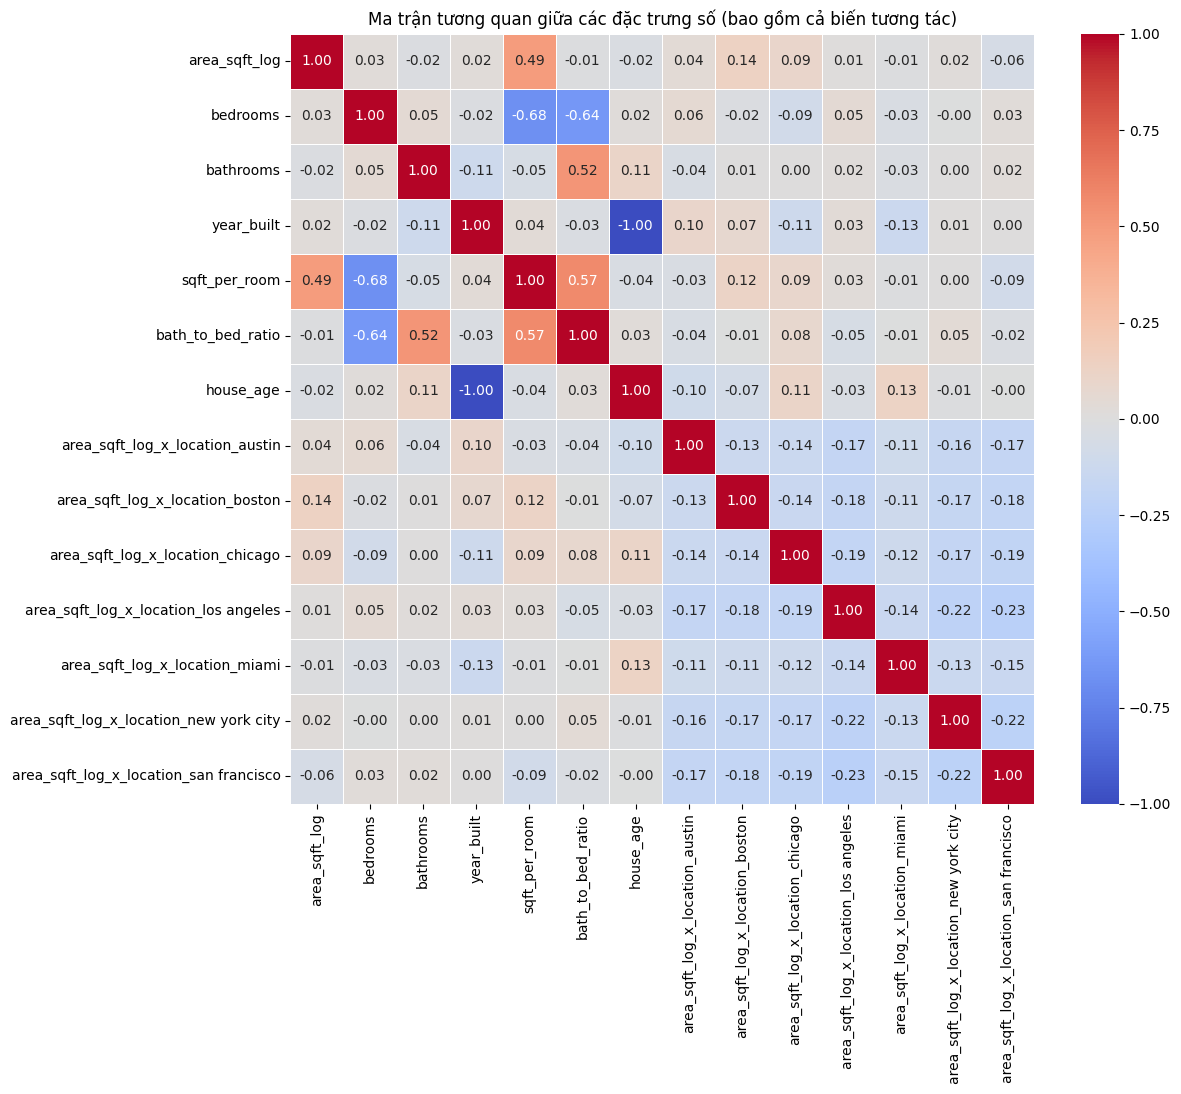

Các cặp đặc trưng có tương quan cao (>0.85 hoặc <-0.85):
[('house_age', 'year_built', np.float64(-0.9999999999999998))]

Bảng điểm số Mutual Information của các đặc trưng độc lập với biến mục tiêu Price:


,Đặc trưng,Điểm số Mutual Information
3,area_sqft_log,0.633964
4,sqft_per_room,0.394757
20,area_sqft_log_x_location_san francisco,0.145424
17,area_sqft_log_x_location_los angeles,0.091587
19,area_sqft_log_x_location_new york city,0.082908
15,area_sqft_log_x_location_boston,0.073079
16,area_sqft_log_x_location_chicago,0.058967
0,bedrooms,0.058263
14,area_sqft_log_x_location_austin,0.045171
10,location_los angeles,0.042105


In [8]:
# 1. Tính toán ma trận tương quan giữa các đặc trưng số để tìm đa cộng tuyến
numeric_features = scale_cols
corr_matrix = X_train_final[numeric_features].corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng số (bao gồm cả biến tương tác)')
plt.show()

# Tìm các cặp đặc trưng tương quan rất mạnh (> 0.85 hoặc < -0.85)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            high_corr.append((colname_i, colname_j, corr_matrix.iloc[i, j]))
print("Các cặp đặc trưng có tương quan cao (>0.85 hoặc <-0.85):")
print(high_corr)

# 2. Đánh giá độ quan trọng của đặc trưng bằng Mutual Information Regression
mi_scores = mutual_info_regression(X_train_final, y_train['price'], random_state=42)
mi_scores_df = pd.DataFrame({
    'Đặc trưng': X_train_final.columns,
    'Điểm số Mutual Information': mi_scores
}).sort_values(by='Điểm số Mutual Information', ascending=False)

print("\nBảng điểm số Mutual Information của các đặc trưng độc lập với biến mục tiêu Price:")
display(mi_scores_df)

## Bước 7. Lưu trữ dữ liệu sạch vào ready_train

Loại bỏ các đặc trưng đa cộng tuyến hoàn hảo (như year_built tương quan -1.0 với house_age) và lưu dữ liệu ra các file CSV.

In [9]:
# 1. Loại bỏ year_built và giữ lại house_age để tránh đa cộng tuyến hoàn hảo
X_train_final = X_train_final.drop(columns=['year_built'])
X_test_final = X_test_final.drop(columns=['year_built'])

# 2. Tạo thư mục data/ready_train nếu chưa có
processed_dir = "../data/ready_train"
if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)
    print(f"Đã tạo thư mục: {processed_dir}")

# 3. Lưu các file CSV đã hoàn tất tiền xử lý
X_train_final.to_csv(os.path.join(processed_dir, "X_train.csv"), index=False)
X_test_final.to_csv(os.path.join(processed_dir, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(processed_dir, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(processed_dir, "y_test.csv"), index=False)

print("\nĐã lưu các file dữ liệu Feature Engineering thành công tại thư mục ready_train:")
print(f"- X_train.csv (Kích thước: {X_train_final.shape})")
print(f"- X_test.csv (Kích thước: {X_test_final.shape})")
print(f"- y_train.csv (Kích thước: {y_train.shape})")
print(f"- y_test.csv (Kích thước: {y_test.shape})")


Đã lưu các file dữ liệu Feature Engineering thành công tại thư mục ready_train:
- X_train.csv (Kích thước: (290, 20))
- X_test.csv (Kích thước: (73, 20))
- y_train.csv (Kích thước: (290, 1))
- y_test.csv (Kích thước: (73, 1))
